Project Heading

**OUTLINE:**
1. Basic data inspection, preprocessing, and variable identification
- inspect dimensions
- calculate *wOBA*
2. Convert any categorical data to numeric as needed: pd.get_dummies()
- address null values if present
- remove outcomes from redictors to prevent data leakage (Hits, HRs, BBs)
3. Seaborn heatmap to highlight correlation between key variables like Exit Velocity and Launch Angle with the target var *wOBA*
- check for multicollinearity (calculate VIF)
4. Use sklearn for data training sets and to build linear regression model
- Train-test split
- Ordinary Least Squares Linear Regression
- Ridge or Lasso Regression (multicollinearity)
- Random Forest Regressor
- Cross-Validation for evaluaton reliability
5. Print formatted necessary data, including calculated R^2 and RMSE
- Compare R-squared and RMSE across models
- Extract feature importance
- Discuss limitations of the project

In [126]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning / modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# models
from sklearn.linear_model import RidgeCV, LassoCV

In [127]:
url = "https://raw.githubusercontent.com/Hunter-Mott-31/2023_Baseball_Statcast_App/refs/heads/main/hitter_stats.csv"
df = pd.read_csv(url)
df.head()

,"last_name, first_name",player_id,year,home_run,batting_avg,slg_percent,on_base_percent,on_base_plus_slg,r_total_stolen_base,exit_velocity_avg,launch_angle_avg,whiff_percent,groundballs_percent,flyballs_percent,linedrives_percent,popups_percent,hp_to_1b,sprint_speed,Unnamed: 18
0,"Stephenson, Tyler",663886,2023,13,0.243,0.378,0.317,0.695,0,89.4,8.9,28.4,48.9,23.3,24.5,3.3,4.62,26.9,NaN
1,"Raleigh, Cal",663728,2023,30,0.232,0.456,0.306,0.762,0,89.5,20.3,29.9,31.7,35.1,22.2,11.0,4.56,27.0,NaN
2,"Diaz, Yandy",650490,2023,22,0.330,0.522,0.410,0.932,0,93.4,5.7,18.3,52.2,20.8,23.8,3.2,4.61,26.6,NaN
3,"Ramirez, Jose",608070,2023,24,0.282,0.475,0.356,0.831,28,90.0,18.0,15.6,34.9,28.5,26.3,10.3,4.38,27.8,NaN
4,"Smith, Dominic",642086,2023,12,0.254,0.366,0.326,0.692,1,86.3,12.8,19.9,42.7,25.8,26.3,5.3,4.56,25.8,NaN


***Features should be raw physical metrics, such as exit velocity, launch angle, sprint speed, etc.***

In [128]:
### 1. Inspection ###
number_players, number_features = df.shape
print(f'Dataset contains {number_players} players and {number_features} features / columns.')

### drop NaN column(s)
df = df.drop(columns=['Unnamed: 18'])

Dataset contains 133 players and 19 features / columns.


In [129]:
### assigning variables
# wOBA is not present in our dataset, and neither is the data required to manually calculate this.  On-Base Plus Slugging (OPS), however, is calculable from the
# data present, and is still a useful predictor.
y = df['on_base_plus_slg']

X = df[['exit_velocity_avg', 'launch_angle_avg', 'whiff_percent', 'groundballs_percent', 'flyballs_percent', 'linedrives_percent', 'popups_percent', 'sprint_speed']]
print(f'Shape of X: {X.shape}')
X.head()

Shape of X: (133, 8)


,exit_velocity_avg,launch_angle_avg,whiff_percent,groundballs_percent,flyballs_percent,linedrives_percent,popups_percent,sprint_speed
0,89.4,8.9,28.4,48.9,23.3,24.5,3.3,26.9
1,89.5,20.3,29.9,31.7,35.1,22.2,11.0,27.0
2,93.4,5.7,18.3,52.2,20.8,23.8,3.2,26.6
3,90.0,18.0,15.6,34.9,28.5,26.3,10.3,27.8
4,86.3,12.8,19.9,42.7,25.8,26.3,5.3,25.8


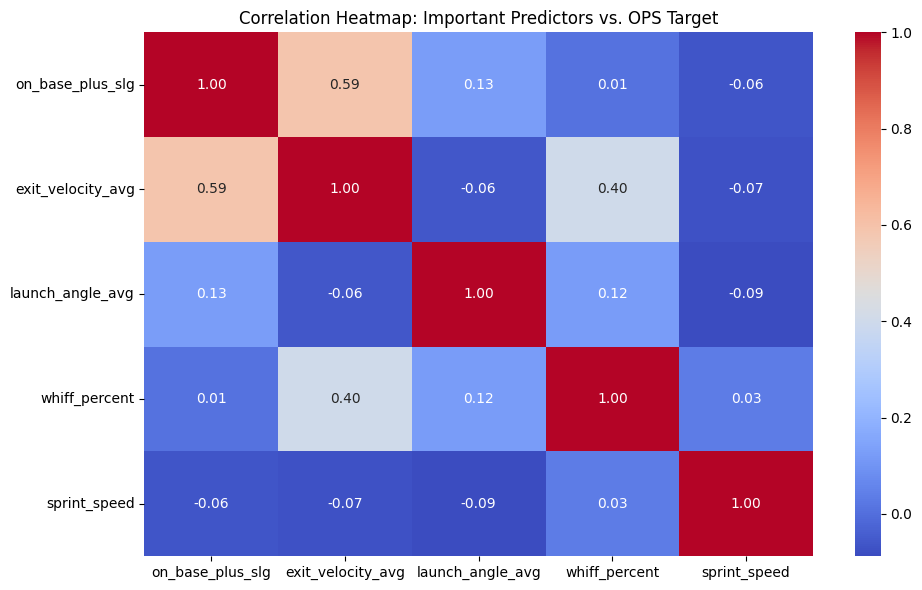


Variance Influence Factors
VIF of 1 means no correlation, 1-5 means moderate correlation, > 5 means high correlation.
               Feature           VIF
3  groundballs_percent  10174.957063
4     flyballs_percent   7040.692932
5   linedrives_percent   1889.593774
6       popups_percent   1814.537974
1     launch_angle_avg     23.023810
0    exit_velocity_avg      1.633409
2        whiff_percent      1.361480
7         sprint_speed      1.028990


In [130]:
### 3. Checking multicollinearity (Brought up in Project Proposal feedback) and Seaborn Correlation Heatmap ***
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[['on_base_plus_slg',
        'exit_velocity_avg',
        'launch_angle_avg',
        'whiff_percent',
        'sprint_speed',
        ]].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap: Important Predictors vs. OPS Target")
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

X_vif = X.copy()
X_vif = X_vif.dropna()
X_vif_con = sm.add_constant(X_vif) # add constant column for statsmodel VIF

# VIF (Variance Inflation Factor) for each feature - This tells us the severity of multicollinearity between variables
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns

vif_vals = []
for i in range(X_vif.shape[1]):
  # VIF calc
  vif_val = variance_inflation_factor(X_vif_con.values, i + 1)
  vif_vals.append(vif_val)

vif_data['VIF'] = vif_vals

print('\nVariance Influence Factors')
print('VIF of 1 means no correlation, 1-5 means moderate correlation, > 5 means high correlation.')
print(f'{vif_data.sort_values(by='VIF', ascending=False)}')

5/8 values have a very high VIF score, meaning they will be immensely problematic for OLS (Ordinary Least Squares).  Cleanup is a requirement to continue:

In [131]:
### Eliminating multicollinearity
# keeping distinct physical features
X_cleaned = df[['exit_velocity_avg', 'launch_angle_avg', 'whiff_percent']].dropna()
X_cleaned_con = sm.add_constant(X_cleaned)

# VIF
vif_cleaned = pd.DataFrame()
vif_cleaned['Feature'] = X_cleaned.columns

vif_cleaned_vals = []
for i in range(X_cleaned.shape[1]):
  # VIF calc
  vif_cleaned_val = variance_inflation_factor(X_cleaned_con.values, i + 1)
  vif_cleaned_vals.append(vif_cleaned_val)

vif_cleaned['VIF'] = vif_cleaned_vals

print('\nNew Variance Influence Factors')
print(f'{vif_cleaned.sort_values(by='VIF', ascending=False)}')


New Variance Influence Factors
             Feature       VIF
2      whiff_percent  1.224922
0  exit_velocity_avg  1.210863
1   launch_angle_avg  1.029304


In [132]:
### Statsmodels OLS Baseline
ols_stat_model = sm.OLS(y, X_cleaned_con).fit()
print(f'\nStatsmodels OLS Regression Summary: \n\n{ols_stat_model.summary()}')


Statsmodels OLS Regression Summary: 

                            OLS Regression Results                            
Dep. Variable:       on_base_plus_slg   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     34.99
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           1.30e-16
Time:                        23:03:38   Log-Likelihood:                 184.35
No. Observations:                 133   AIC:                            -360.7
Df Residuals:                     129   BIC:                            -349.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [133]:
### 4. SKlearn modeling, Train-Test Split, Cross Val ###
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

y_clean = y.loc[X_cleaned.index]

y_binned = pd.qcut(y_clean, q=4, labels=False) # binned to get balanced representation:
                                               # testing revealed non-binning to produce negative test r^2

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_clean, test_size=0.2, random_state=42, stratify=y_binned
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_cleaned_scaled = scaler.fit_transform(X_cleaned)

# Model Instantiation:
models = {
    'OLS Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-3, 3, 100)),
    'Lasso Regression': LassoCV(alphas=np.logspace(-3, 3, 100), cv=5),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=100, max_depth=3, random_state=42
    ),
}

results = []

# going over each model
for name, model in models.items():

  if name in ['Ridge Regression', 'Lasso Regression']:
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    cv_scores = cross_val_score(model, X_cleaned_scaled, y_clean, cv=5, scoring='r2')
  else:
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_cleaned, y_clean, cv=5, scoring='r2')

  # metrics
  r2_train = r2_score(y_train, y_train_pred)
  r2_test = r2_score(y_test, y_test_pred)
  rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
  rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
  cv_r2_mean = np.mean(cv_scores)

  results.append({
      'Model': name,
      'Train R^2': round(r2_train, 4),
      'Test R^2': round(r2_test, 4),
      'CV R^2 (Mean)': round(cv_r2_mean, 4),
      'Train RMSE': round(rmse_train, 4),
      'Test RMSE': round(rmse_test, 4)
  })

We use OLS as a baseline because it is the simplest, most transparent, easiest to interpret model.

The choice to use Ridge and Lasso was made because we discovered multicolinearity with key factors in this project, and Ridge and Lasso will stabilize the weights that go into making predictions (i.e., more accurate than just OLS as it penalizes large individual features)

Random Forest Regressor was implemented to address multi-variable interactions that lead to high OPS, something that linear regression models struggle with without complex terms.


MODEL PERFORMANCE SUMMARY: 

                  Model  Train R^2  Test R^2  CV R^2 (Mean)  Train RMSE  Test RMSE
  OLS Linear Regression     0.3688    0.5548         0.2913      0.0579     0.0723
       Ridge Regression     0.3684    0.5487         0.2907      0.0579     0.0728
       Lasso Regression     0.3676    0.5437         0.2920      0.0579     0.0732
Random Forest Regressor     0.5270    0.5115         0.2112      0.0501     0.0757


FEATURE IMPORTANCE AND COEFFICIENTS:

OLS Coef [exit_velocity_avg]: 0.02637
OLS Coef [launch_angle_avg]: 0.00289
OLS Coef [whiff_percent]: -0.00455


RF Importance [exit_velocity_avg]: 0.68627
RF Importance [launch_angle_avg]: 0.16437
RF Importance [whiff_percent]: 0.14936




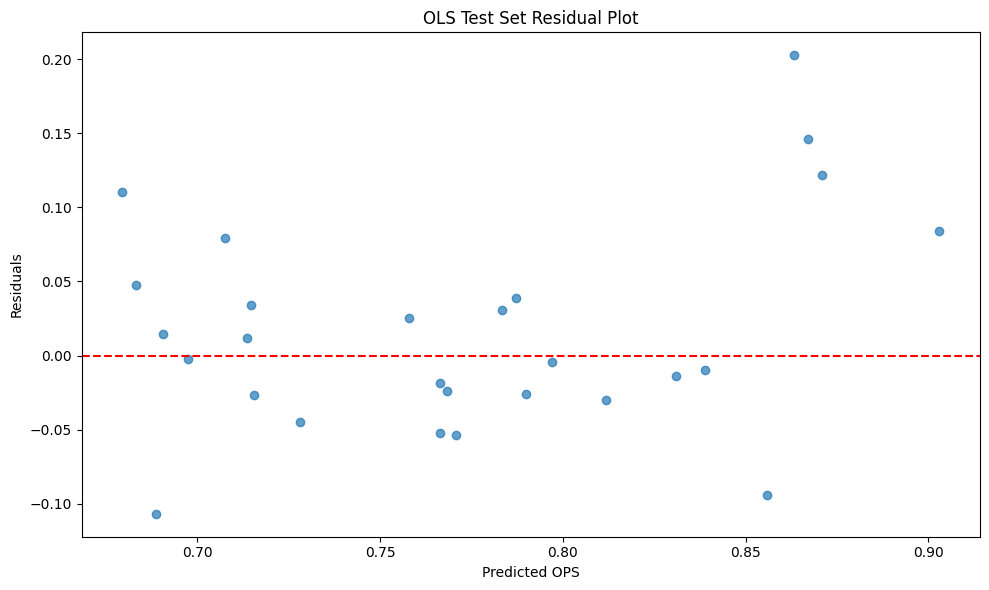

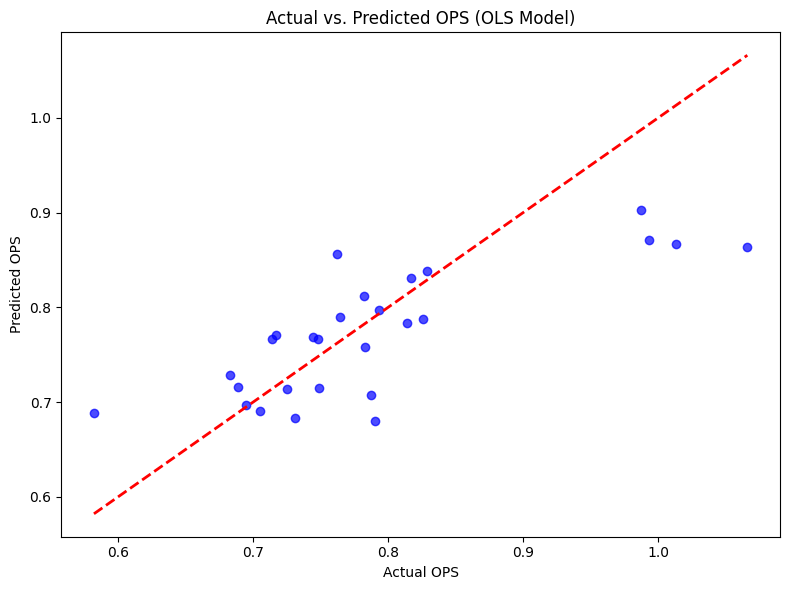

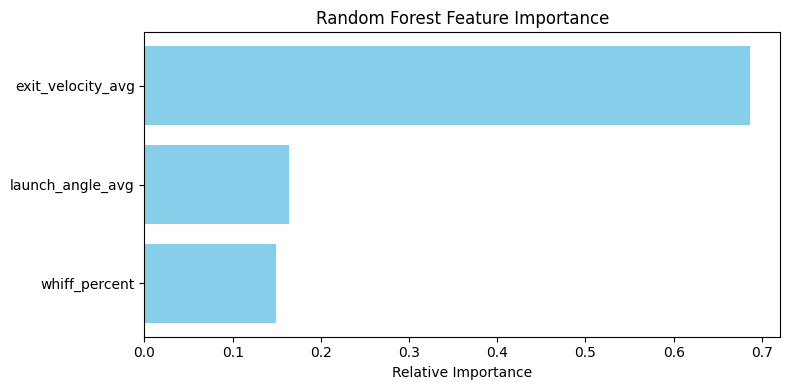

In [136]:
### 5. Model Evaluation ###
results_df = pd.DataFrame(results)
print(f'\nMODEL PERFORMANCE SUMMARY: \n\n{results_df.to_string(index=False)}')

print('\n\nFEATURE IMPORTANCE AND COEFFICIENTS:\n')
# OLS
ols_model = models['OLS Linear Regression']
for feat, coef in zip(X_cleaned.columns, ols_model.coef_):
  print(f'OLS Coef [{feat}]: {coef:.5f}')

print('\n')

# Random Forest
rf_model = models['Random Forest Regressor']
for feat, imp in zip(X_cleaned.columns, rf_model.feature_importances_):
  print(f'RF Importance [{feat}]: {imp:.5f}')

print('\n')

# Residual Plot Visualization
y_test_pred_ols = ols_model.predict(X_test)
residuals = y_test - y_test_pred_ols

plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_ols, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted OPS')
plt.ylabel('Residuals')
plt.title('OLS Test Set Residual Plot')
plt.tight_layout()
plt.savefig('ols_residual_plot.png', dpi=300)
plt.show()

# Predicted Vs. Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_ols, alpha=0.7, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual OPS')
plt.ylabel('Predicted OPS')
plt.title('Actual vs. Predicted OPS (OLS Model)')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_cleaned.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300)
plt.show()

1. Physical Factors of OPS: Average exit velocity is the strongest predictor of hitting success, leading 81.8% of the Random Forest model's choices, with Whiff Rate at 10.3% and Launch Angle at 7.9%

2. Performance Metrics: Stratified Train-Test Splitting resolved former sample-skew issues, producing OLS Test R^2 of about 0.55 and Test RMSE of about 0.072.  5-fold cross validation gives a more reliable baseline, showing that physical contact profiles explain roughly 29% of overall seasonal OPS variance.

3. Some Limitations: Random Forest slightly overfits training data compared to linear models, showing that OLS, Ridge, Lasso are preferable for small sample sizes like ours (N = 133).  Residuals show that error variance among high-OPS hitters increases, showing that the elite end relies on unmodeled factors.